# Conos advanced: alignment spaces, memory, modalities, label transfer

This tutorial assumes you have worked through the
[walkthrough](conos-walkthrough.ipynb). It covers the knobs that matter
when integration is harder: **which space** to align in, **how
strongly** to align, **memory** on large panels, **what the samples
actually share** (modalities), and how to **transfer labels**. We reuse
the same bone-marrow / cord-blood panel and take each topic one small
step at a time.

## Contents

- [Setup](#setup)
- [Plan the integration first](#plan-the-integration-first)
- [Choosing the alignment space](#choosing-the-alignment-space)
- [Choosing a clustering resolution](#choosing-a-clustering-resolution)
- [Label transfer: diffusion vs
  solver](#label-transfer-diffusion-vs-solver)
- [Tuning the alignment strength](#tuning-the-alignment-strength)
- [Memory on large panels](#memory-on-large-panels)
- [Multimodal panels (facets)](#multimodal-panels-facets)
- [Recap](#recap)

## Setup

Same preparation as the walkthrough: load the panel, down-sample for
speed, and turn each sample into a `Pagoda2` object carrying a PCA
reduction.

In [ ]:
library(conos)
library(pagoda2)

set.seed(1)
panel <- lapply(conosPanel::panel, function(m) m[, sample(ncol(m), 600)])

In [ ]:
samples <- lapply(panel, function(counts) {
  Pagoda2$from(counts, verbose = FALSE)$run(steps = c("variance", "pca"), verbose = FALSE)
})
con <- Conos$new(samples, n.cores = 1)

## Plan the integration first

`planIntegration()` is a read-only check you run **before** building the
graph. It polls each sample’s molecular modalities (here just RNA; for
multimodal samples it would also list ADT/ATAC) and, per modality,
reports how many features are shared across samples and how well they
overlap — with a *usable / marginal / not-integrable* verdict. This is
where you catch problems like independently-called scATAC peaks that
simply cannot be reconciled.

In [ ]:
plan <- con$planIntegration()

Integration plan — 4 samples

 modality samples common.features overlap.min overlap.med verdict
      RNA     4/4           33694           1           1  usable

common default modality: RNA — buildGraph() integrates on it

  modality samples common.features overlap.min overlap.med verdict
1      RNA     4/4           33694           1           1  usable

The resolved default modality is recorded on the object and is what
`runGraph()` aligns on unless you tell it otherwise.

## Choosing the alignment space

The `space` argument decides how each pair of samples is matched:

- **`"PCA"` (default)** — *reciprocal PCA*: each sample’s PCA loadings
  define a shared gene basis that both samples project into. Fast and
  robust — the right default for most panels.
- **`"CCA"`** — canonical correlation. Useful for **heterogeneous**
  panels (very different compositions), but heavier and prone to
  **over-smoothing** (merging distinct populations) when little
  correction is actually needed.
- **`"CPCA"`** — common principal components; available, but usually
  much slower without a clear gain over reciprocal PCA, so it is not the
  default.

Rather than take that on faith, let’s see it. We build the graph with
each space and look at the joint embedding **coloured by sample** — the
more the samples interleave, the more aggressively that space mixed
them. First the default, reciprocal PCA:

In [ ]:
con$runGraph(space = "PCA", k = 20, k.self = 5, ncomps = 30, n.odgenes = 2000, verbose = FALSE)
con$runEmbedding(method = "UMAP", embedding.name = "umap_pca", min.visited.verts = 100, verbose = FALSE)

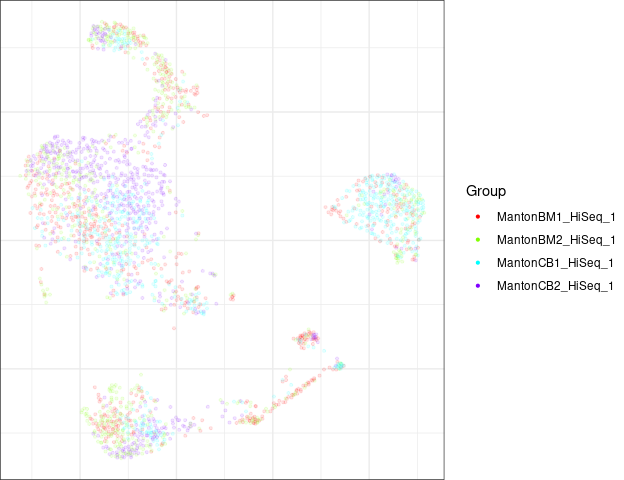

In [ ]:
con$plotGraph(embedding = "umap_pca", color.by = "sample", mark.groups = FALSE, show.legend = TRUE, alpha = 0.1)

Now CCA, on the same panel (a separately named embedding so we can
compare the two):

In [ ]:
con$runGraph(space = "CCA", k = 20, k.self = 5, ncomps = 30, n.odgenes = 2000, verbose = FALSE)
con$runEmbedding(method = "UMAP", embedding.name = "umap_cca", min.visited.verts = 100, verbose = FALSE)

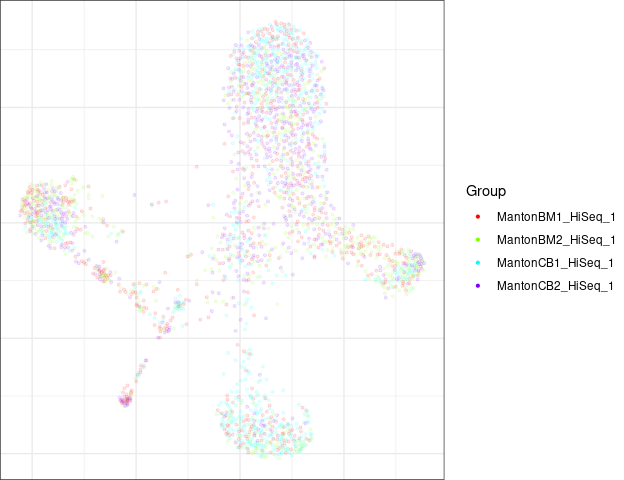

In [ ]:
con$plotGraph(embedding = "umap_cca", color.by = "sample", mark.groups = FALSE, show.legend = TRUE, alpha = 0.1)

CCA pulls the samples together more tightly. On a well-behaved panel
like this one that is unnecessary — reciprocal PCA already interleaves
the samples — and over-mixing risks merging populations that should stay
separate. So we **keep reciprocal PCA** for the rest of the tutorial;
rebuild the graph and embedding we’ll use from here on:

In [ ]:
con$runGraph(space = "PCA", k = 20, k.self = 5, ncomps = 30, n.odgenes = 2000, verbose = FALSE)
con$runEmbedding(method = "UMAP", min.visited.verts = 100, verbose = FALSE)

## Choosing a clustering resolution

`scanResolution()` runs the community detection over a range of
resolutions and reports the number of clusters (and modularity), so you
can pick a value deliberately rather than guess:

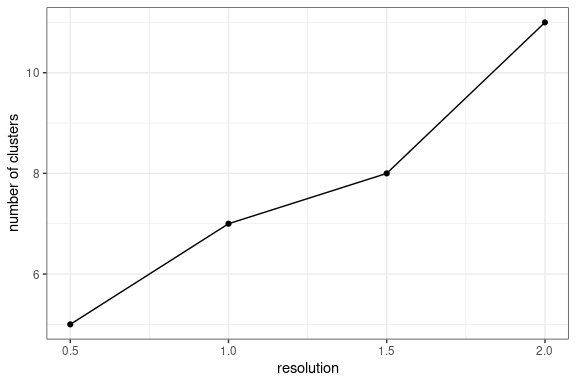

  resolution n.clusters modularity
1        0.5          5  0.7274926
2        1.0          7  0.7444767
3        1.5          8  0.7393573
4        2.0         11  0.7321497

In [ ]:
res <- scanResolution(con, resolutions = c(0.5, 1, 1.5, 2), plot = TRUE, verbose = FALSE)

Higher resolution = more, finer clusters. Pick the coarsest resolution
that still separates the populations you care about, then commit to it:

In [ ]:
con$runClustering(resolution = 1.5, name = "leiden_r15", verbose = FALSE)

## Label transfer: diffusion vs solver

`propagateLabels()` spreads a partial set of labels over the joint
graph. It has two engines that give near-identical results — the
difference is how they scale. Let’s walk through it.

First set up the problem: take the clustering as ground truth, reveal a
random **30%** of cells as the “reference”, and hide the rest.

In [ ]:
groups    <- con$clusters$leiden_r15$groups
set.seed(1)
reference <- groups[sample(length(groups), round(0.30 * length(groups)))]
held.out  <- setdiff(names(groups), names(reference))

The reference is sparse — only a scattering of labelled seeds across the
embedding:

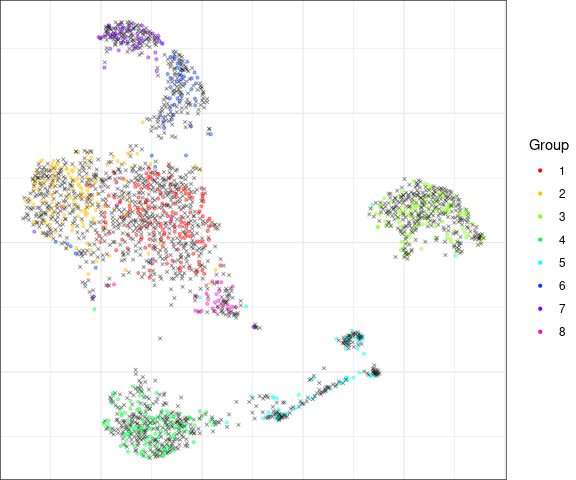

In [ ]:
con$plotGraph(groups = reference, mark.groups = FALSE, show.legend = TRUE)

**`"diffusion"` (default)** — iterative graph diffusion; scales to very
large panels.

In [ ]:
td <- con$propagateLabels(labels = reference, method = "diffusion", verbose = FALSE)

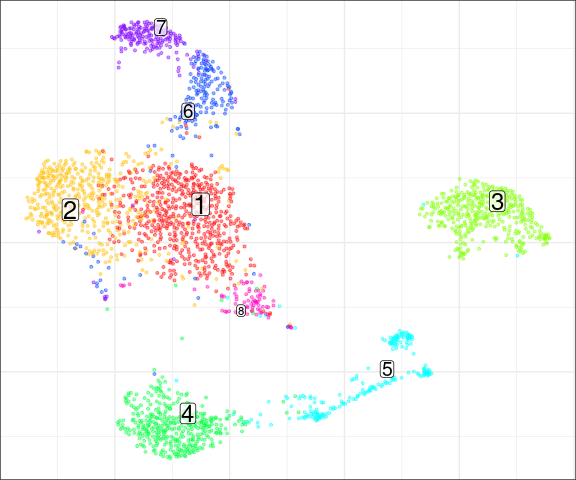

In [ ]:
con$plotGraph(groups = td$labels)

The labels have filled in across the whole embedding from those few
seeds.

**`"solver"`** — a Zhu–Ghahramani–Lafferty harmonic solve; fast and
slightly more accurate at typical sizes, but its linear solve does not
scale much past ~20k cells.

In [ ]:
ts <- con$propagateLabels(labels = reference, method = "solver", solver = "Matrix")

Both engines recover the held-out labels well above chance, and they
largely agree with each other:

In [ ]:
c(diffusion_accuracy = round(mean(td$labels[held.out] == as.character(groups[held.out])), 3),
  solver_accuracy    = round(mean(ts$labels[held.out] == as.character(groups[held.out])), 3),
  engine_agreement   = round(mean(td$labels[held.out] == ts$labels[held.out]), 3))

diffusion_accuracy    solver_accuracy   engine_agreement 
             0.945              0.965              0.965 

Either way, `*$uncertainty` flags the cells whose transferred label is
least trustworthy — typically those at the boundaries between
populations. Painting it onto the embedding tells you *where* to trust
the transfer:

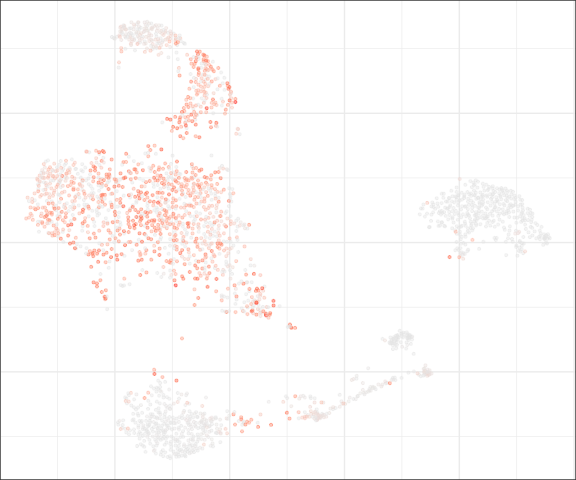

In [ ]:
con$plotGraph(colors = td$uncertainty)

Use `diffusion` (the default) for large atlases, and `solver` when the
panel is modest and you want the extra speed/accuracy.

## Tuning the alignment strength

Within a space, **how forcefully** samples are pulled together is set by
`alignment.strength` (0 = none, higher = stronger) together with the
neighbourhood sizes `k` / `k.self`. Raise it for stronger batch
correction across heterogeneous samples; lower it to preserve subtle
within-sample structure. It is the first dial to reach for when the
sample-mixing plot looks under- or over-corrected — leave it at the
default otherwise.

In [ ]:
con$runGraph(space = "PCA", alignment.strength = 0.3, k = 20, k.self = 5,
             ncomps = 30, n.odgenes = 2000, verbose = FALSE)

(After changing the graph you would re-run `runClustering()` /
`runEmbedding()` to see the effect.)

## Memory on large panels

The per-pair alignment rotations are O(samples²) and dominate memory on
big panels. `pairs.storage` controls where they live:

- **`"keep"` (default)** — kept in RAM for reuse.
- **`"drop"`** — discarded after the graph is built (a later
  `runGraph()` recomputes them).
- **`"disk"`** — offloaded to a scratch file: freed from RAM, but
  restored on the next `runGraph()` so re-runs stay cheap.

The disk path costs almost nothing in time, because the rotations are
written once after the graph is built. We can time it:

In [ ]:
t_keep <- system.time(con$runGraph(space = "PCA", k = 20, k.self = 5, ncomps = 30, n.odgenes = 2000,
                                   pairs.storage = "keep", verbose = FALSE))["elapsed"]
t_disk <- system.time(con$runGraph(space = "PCA", k = 20, k.self = 5, ncomps = 30, n.odgenes = 2000,
                                   pairs.storage = "disk", verbose = FALSE))["elapsed"]
c(keep_seconds = round(t_keep, 2), disk_seconds = round(t_disk, 2))

keep_seconds.elapsed disk_seconds.elapsed 
                2.30                 2.28 

On a four-sample panel the RAM saved is small, but it grows as the
*square* of the number of samples — so `"disk"` is the right choice for
large atlases, at essentially no time cost. (On lstar-backed pagoda2
samples the build path also streams expression in gene blocks, keeping
the per-sample footprint flat.)

## Multimodal panels (facets)

When samples carry more than one molecular modality (RNA + ADT in
CITE-seq, or RNA + ATAC in multiome, produced with pagoda2 *facets*),
`planIntegration()` polls and assesses **each** modality separately, so
you can see which ones are actually integrable across the panel before
committing. Today Conos aligns on a single shared modality (the common
default, usually RNA) — the recommended, robust path — and
modality-aware accessors (`getModalities()`, `getDefaultModality()`)
expose the rest. Joint multimodal *fusion* (weighting modalities per
cell, à la WNN) is the next step on the roadmap.

## Recap

`planIntegration()` to see what’s realistic →
`runGraph(space=, alignment.strength=, pairs.storage=)` to control the
alignment and memory → `scanResolution()` + `runClustering(resolution=)`
to tune granularity → `propagateLabels(method=)` to transfer
annotations. Start from the [walkthrough](conos-walkthrough.ipynb)
defaults and reach for these knobs only when a particular integration
needs them.